In [ ]:
import gayum
import plotnine as p9
from plotnine.data import mtcars

In [2]:

f = gayum.Formula(response='mpg', terms=gayum.terms.s('hp'), df=mtcars)
model = gayum.GAM(formula=f)

X, y = mtcars[['hp']], mtcars[['mpg']]
model = model.fit(X, y)

pred_df = mtcars[['hp', 'mpg']]
pred_df['pred'] = model.predict(X)

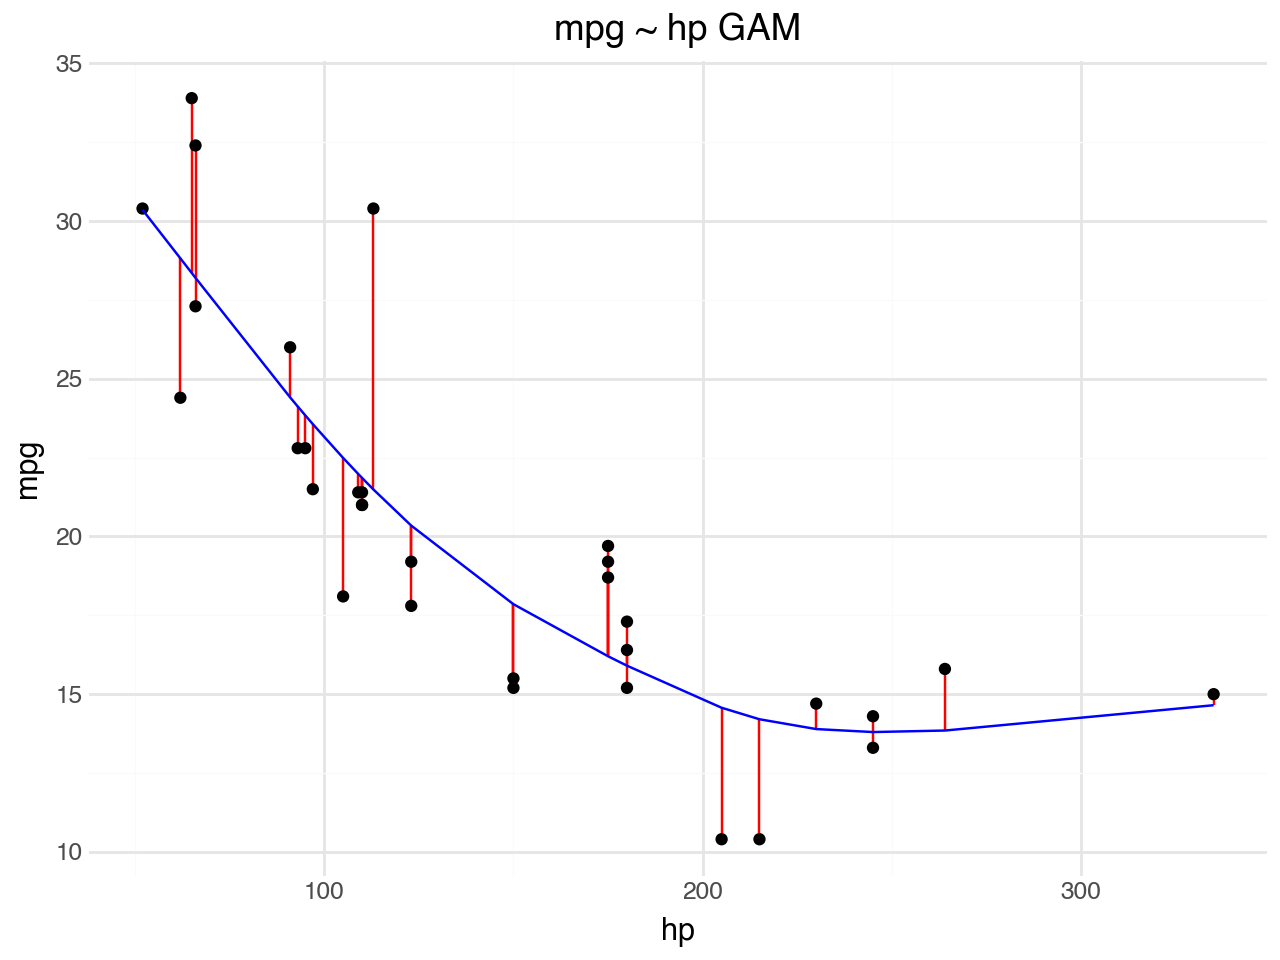

In [3]:
(
    p9.ggplot()
    + p9.geom_segment(data=pred_df, mapping=p9.aes(x='hp', xend='hp', y='mpg', yend='pred'), color='red')
    + p9.geom_point(data=pred_df, mapping=p9.aes(x='hp', y='mpg'))
    + p9.geom_line(data=pred_df, mapping=p9.aes(x='hp', y='pred'), color='blue')
    + p9.theme_minimal()
    + p9.labs(title='mpg ~ hp GAM')
).show()